In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

df = pd.read_csv("HR_Attrition.csv")

print("FIRST 10 ROWS")
display(df.head(10))

print("SHAPE:", df.shape)

print("TARGET COUNTS")
print(df['Attrition'].value_counts())

attrition_rate = (
    (df['Attrition']=="Yes").mean()*100
)

print("ATTRITION RATE:", attrition_rate)

drop_cols = [
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

categorical_cols = df.select_dtypes(
    include=['object']
).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression":
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),

    "Random Forest":
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)

    if hasattr(model,"predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,prob)
    else:
        auc = 0

    results.append([
        name,
        precision,
        recall,
        f1,
        auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

print(results_df)

FIRST 10 ROWS


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


SHAPE: (1470, 35)
TARGET COUNTS
Attrition
No     1233
Yes     237
Name: count, dtype: int64
ATTRITION RATE: 16.122448979591837
                 Model  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.341176  0.617021  0.439394  0.798605
1        Random Forest   0.500000  0.063830  0.113208  0.775218
2    Gradient Boosting   0.611111  0.234043  0.338462  0.793781


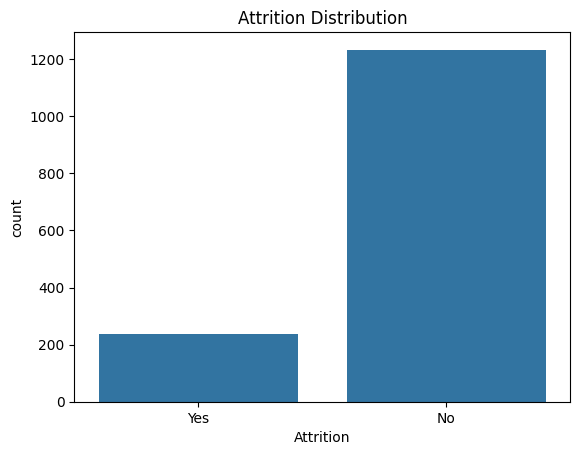

In [5]:
attr_dept = pd.crosstab(
    df['Department_Research & Development']
    if 'Department_Research & Development' in df.columns else y,
    y
)

sns.countplot(
    x='Attrition',
    data=pd.read_csv("HR_Attrition.csv")
)

plt.title("Attrition Distribution")
plt.savefig("chart1_attrition_distribution.png")
plt.show()

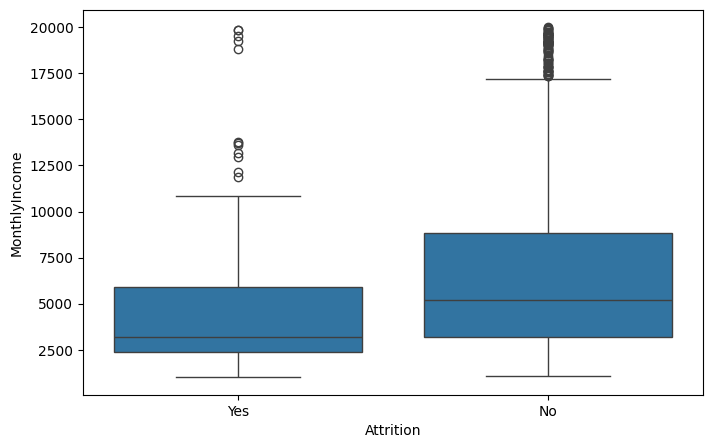

In [6]:
raw = pd.read_csv("HR_Attrition.csv")

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=raw
)

plt.savefig("chart2_income_vs_attrition.png")

plt.show()

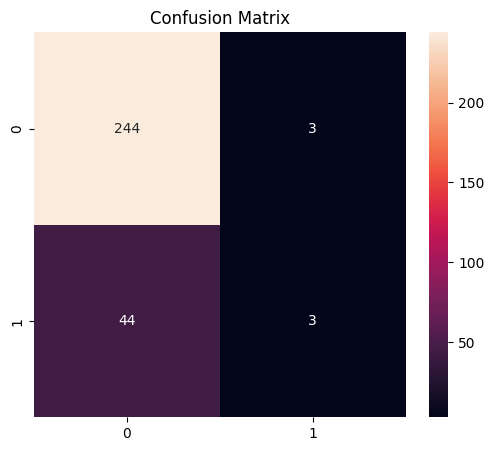

In [7]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.savefig(
    "chart3_confusion_matrix.png"
)

plt.show()

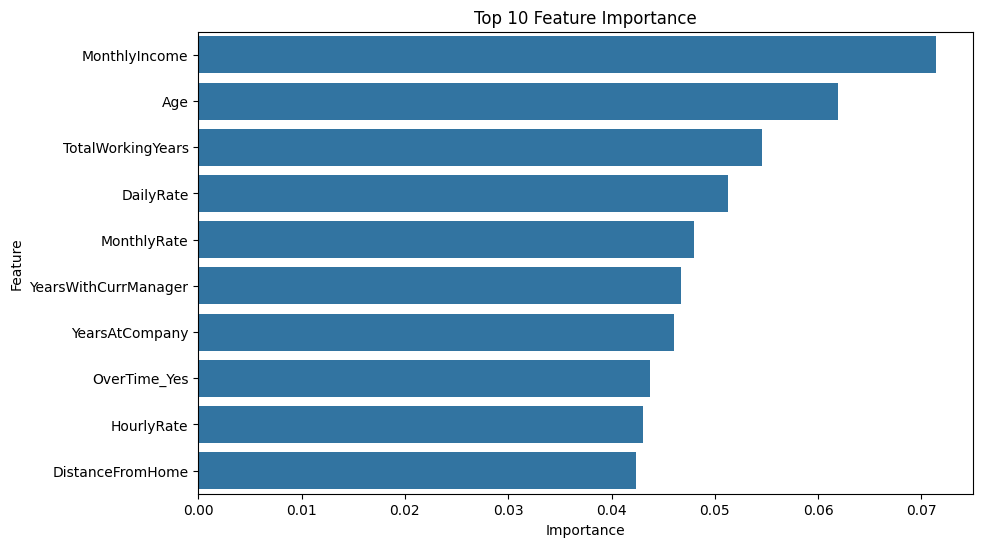

                 Feature  Importance
10         MonthlyIncome    0.071443
0                    Age    0.061937
17     TotalWorkingYears    0.054522
1              DailyRate    0.051280
11           MonthlyRate    0.047951
23  YearsWithCurrManager    0.046725
20        YearsAtCompany    0.046042
44          OverTime_Yes    0.043751
6             HourlyRate    0.043070
2       DistanceFromHome    0.042327


In [8]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title(
    "Top 10 Feature Importance"
)

plt.savefig(
    "chart4_feature_importance.png"
)

plt.show()

print(
importance.head(10)
)

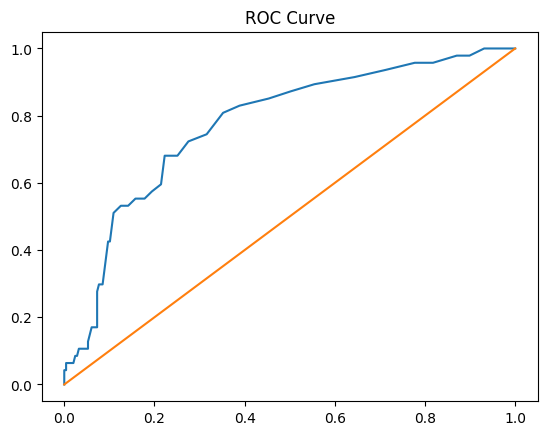

In [9]:
prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.plot(fpr,tpr)

plt.plot(
    [0,1],
    [0,1]
)

plt.title("ROC Curve")

plt.savefig(
    "chart5_roc_curve.png"
)

plt.show()